Shrushti Sakat   
INTERNSHIP ID : IN226049402

In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [9]:
# =========================
# Configuration
# =========================

MODEL_NAME = 'bert-base-uncased'
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 1              # Set to 2-3 for stronger final performance
LEARNING_RATE = 2e-5    # Mandatory as per assignment

# Runtime control for local execution
USE_SUBSET = True
SUBSET_SIZE = 1000      # Stratified sample size used when USE_SUBSET=True (reduced from 2000 for faster execution)

# Pre-configured for your uploaded IMDB dataset
CSV_PATH = 'IMDB Dataset.csv'
TEXT_COLUMN = 'review'
LABEL_COLUMN = 'sentiment'

# IMDB label mapping
LABEL_MAP = {'negative': 0, 'positive': 1}

In [10]:
# =========================
# Data Loading + Preprocessing
# =========================

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f'CSV file not found at: {CSV_PATH}. Please update CSV_PATH.')

df = pd.read_csv(CSV_PATH)
print('Original shape:', df.shape)

required_cols = [TEXT_COLUMN, LABEL_COLUMN]
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f'Missing required column: {col}. Available columns: {list(df.columns)}')

# Keep only required columns
df = df[[TEXT_COLUMN, LABEL_COLUMN]].copy()

# Handle missing values
df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN], inplace=True)

# Basic text cleaning tailored for IMDB reviews
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str).apply(clean_text)

# Drop duplicate text rows
df.drop_duplicates(subset=[TEXT_COLUMN], inplace=True)

# Map labels to integers
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str).str.lower().str.strip()
unique_labels = set(df[LABEL_COLUMN].unique())
unknown_labels = unique_labels - set(LABEL_MAP.keys())
if unknown_labels:
    raise ValueError(f'Found labels not in LABEL_MAP: {unknown_labels}. Available: {sorted(unique_labels)}')
df[LABEL_COLUMN] = df[LABEL_COLUMN].map(LABEL_MAP)
if df[LABEL_COLUMN].isna().any():
    missing_count = int(df[LABEL_COLUMN].isna().sum())
    raise ValueError(f'{missing_count} labels could not be mapped (null after map). Check LABEL_MAP configuration.')
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(int)

# Optional stratified subset for faster local runs
if USE_SUBSET and SUBSET_SIZE < len(df):
    parts = []
    for label_value, group in df.groupby(LABEL_COLUMN):
        n = max(1, int(SUBSET_SIZE * len(group) / len(df)))
        parts.append(group.sample(n, random_state=SEED))
    df = pd.concat(parts).reset_index(drop=True)
    print(f'Subset enabled. New shape: {df.shape}')
print('Cleaned shape:', df.shape)
print('Class distribution:')
print(df[LABEL_COLUMN].value_counts(normalize=True).sort_index())
df.head()

Original shape: (50000, 2)
Subset enabled. New shape: (999, 2)
Cleaned shape: (999, 2)
Class distribution:
sentiment
0    0.498498
1    0.501502
Name: proportion, dtype: float64


,review,sentiment
0,this is the most disturbing film i have ever s...,0
1,this movie was probably one of the worst movie...,0
2,this is by far the worst non english horror mo...,0
3,blue desert may have had the potential to be e...,0
4,the writer director of this film obviously doe...,0


In [12]:
# =========================
# Train / Validation / Test Split
# =========================

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df[LABEL_COLUMN]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_df[LABEL_COLUMN]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Train:', train_df.shape, 'Val:', val_df.shape, 'Test:', test_df.shape)

Train: (799, 2) Val: (100, 2) Test: (100, 2)


In [13]:
# =========================
# Tokenization + Dataset + DataLoaders
# =========================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
num_labels = len(sorted(df[LABEL_COLUMN].unique()))
id_to_label = {i: str(i) for i in range(num_labels)}
label_to_id = {str(i): i for i in range(num_labels)}

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        item = {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }
        return item

train_dataset = TextDataset(
    train_df[TEXT_COLUMN].tolist(),
    train_df[LABEL_COLUMN].tolist(),
    tokenizer,
    MAX_LENGTH
)

val_dataset = TextDataset(
    val_df[TEXT_COLUMN].tolist(),
    val_df[LABEL_COLUMN].tolist(),
    tokenizer,
    MAX_LENGTH
)

test_dataset = TextDataset(
    test_df[TEXT_COLUMN].tolist(),
    test_df[LABEL_COLUMN].tolist(),
    tokenizer,
    MAX_LENGTH
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('DataLoaders are ready.')

DataLoaders are ready.


In [14]:
# =========================
# Utility Functions
# =========================

def compute_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

def evaluate_model(model, data_loader):
    model.eval()
    losses = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            logits = outputs.logits

            losses.append(loss.item())
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    metrics = compute_metrics(all_labels, all_preds)
    avg_loss = float(np.mean(losses)) if losses else 0.0
    return avg_loss, metrics, np.array(all_labels), np.array(all_preds)

def train_one_epoch(model, data_loader, optimizer):
    model.train()
    losses = []

    for batch in tqdm(data_loader, desc='Training', leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses)) if losses else 0.0

In [15]:
# =========================
# Experiment Setup
# =========================

def set_trainable_layers(model, strategy='full'):
    # Start by freezing everything
    for param in model.bert.parameters():
        param.requires_grad = False

    # Classifier head should always be trainable
    for param in model.classifier.parameters():
        param.requires_grad = True

    if strategy == 'freeze_bert':
        # Only classifier trains
        pass
    elif strategy == 'last2':
        # Unfreeze last two encoder layers
        for layer in model.bert.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True
    elif strategy == 'full':
        # Unfreeze all BERT layers
        for param in model.bert.parameters():
            param.requires_grad = True
    else:
        raise ValueError("strategy must be one of: 'freeze_bert', 'last2', 'full'")

def run_experiment(strategy='full'):
    print(f'\n===== Running experiment: {strategy} =====')

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id_to_label,
        label2id=label_to_id
    ).to(device)

    set_trainable_layers(model, strategy=strategy)

    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

    best_val_f1 = -1.0
    best_state_dict = None

    history = []

    for epoch in range(1, EPOCHS + 1):
        print(f'\nEpoch {epoch}/{EPOCHS}')

        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_loss, val_metrics, _, _ = evaluate_model(model, val_loader)

        epoch_log = {
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }
        history.append(epoch_log)

        print(
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | Val F1: {val_metrics['f1']:.4f}"
        )

        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Load best checkpoint based on validation F1
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        model.to(device)

    test_loss, test_metrics, y_true, y_pred = evaluate_model(model, test_loader)

    print('\nTest Metrics:')
    print(test_metrics)

    return {
        'strategy': strategy,
        'history': pd.DataFrame(history),
        'test_loss': test_loss,
        'test_metrics': test_metrics,
        'y_true': y_true,
        'y_pred': y_pred
    }

In [16]:
# =========================
# Run Required Experiments
# =========================

import time

experiment_strategies = ['freeze_bert', 'last2', 'full']
results = {}

print('Starting experiments... (expect ~5-7 minutes total for 3 strategies)')
print('='*70)
start_time = time.time()

for i, strategy in enumerate(experiment_strategies, 1):
    print(f'\n[{i}/3] Starting {strategy} experiment...')
    exp_start = time.time()
    results[strategy] = run_experiment(strategy=strategy)
    exp_time = time.time() - exp_start
    print(f'✓ {strategy} completed in {exp_time:.1f}s')

total_time = time.time() - start_time
print(f'\n{"="*70}')
print(f'All experiments completed in {total_time:.1f}s ({total_time/60:.1f} minutes)')

Starting experiments... (expect ~5-7 minutes total for 3 strategies)

[1/3] Starting freeze_bert experiment...

===== Running experiment: freeze_bert =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/1


Training:   0%|          | 0/50 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/1


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Train Loss: 0.6955 | Val Loss: 0.5945 | Val Acc: 0.7600 | Val F1: 0.7500

Test Metrics:
{'accuracy': 0.8, 'precision': 0.8255208333333333, 'recall': 0.8, 'f1': 0.7960016319869442}
✓ full completed in 421.7s

All experiments completed in 826.0s (13.8 minutes)


,strategy,accuracy,precision,recall,f1,test_loss
0,full,0.80,0.825521,0.80,0.796002,0.596748
1,last2,0.73,0.732323,0.73,0.729323,0.640873
2,freeze_bert,0.50,0.250000,0.50,0.333333,0.694388


C:\Users\Shrushti\AppData\Local\Temp\ipykernel_27856\172018396.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='strategy', y='f1', palette='viridis')


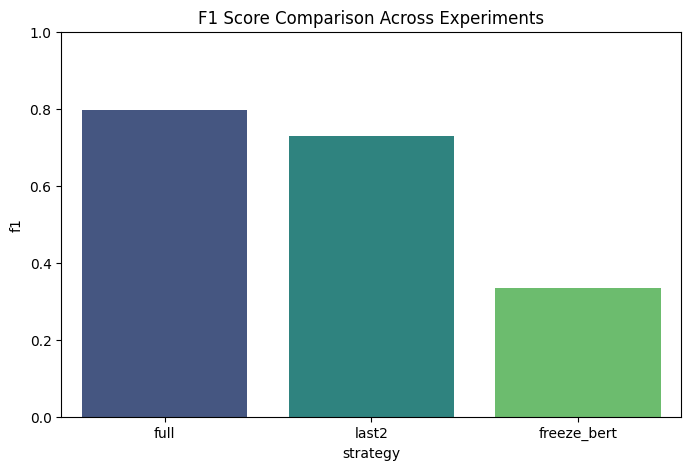

In [17]:
# =========================
# Compare Experiment Performance
# =========================

comparison_rows = []
for strategy, output in results.items():
    metrics = output['test_metrics']
    comparison_rows.append({
        'strategy': strategy,
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'test_loss': output['test_loss']
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(by='f1', ascending=False).reset_index(drop=True)
display(comparison_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x='strategy', y='f1', palette='viridis')
plt.title('F1 Score Comparison Across Experiments')
plt.ylim(0, 1)
plt.show()

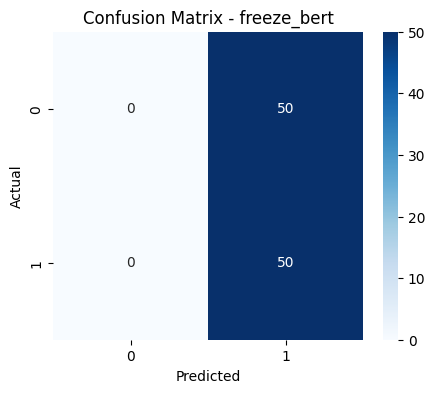

Classification Report - freeze_bert
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.50      1.00      0.67        50

    accuracy                           0.50       100
   macro avg       0.25      0.50      0.33       100
weighted avg       0.25      0.50      0.33       100

----------------------------------------------------------------------


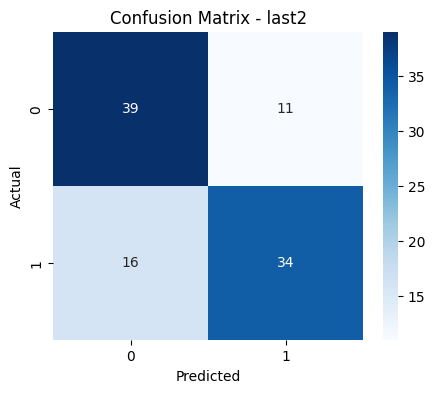

Classification Report - last2
              precision    recall  f1-score   support

           0       0.71      0.78      0.74        50
           1       0.76      0.68      0.72        50

    accuracy                           0.73       100
   macro avg       0.73      0.73      0.73       100
weighted avg       0.73      0.73      0.73       100

----------------------------------------------------------------------


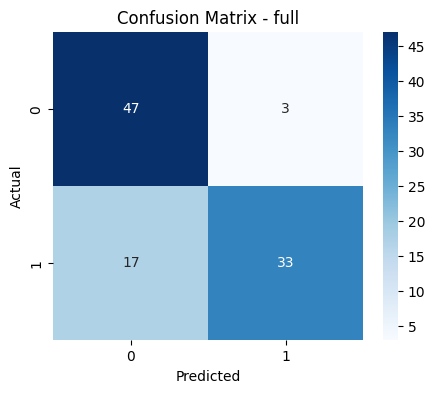

Classification Report - full
              precision    recall  f1-score   support

           0       0.73      0.94      0.82        50
           1       0.92      0.66      0.77        50

    accuracy                           0.80       100
   macro avg       0.83      0.80      0.80       100
weighted avg       0.83      0.80      0.80       100

----------------------------------------------------------------------


In [18]:
# =========================
# Confusion Matrices + Classification Reports
# =========================

for strategy, output in results.items():
    y_true = output['y_true']
    y_pred = output['y_pred']

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {strategy}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(f'Classification Report - {strategy}')
    print(classification_report(y_true, y_pred, zero_division=0))
    print('-' * 70)